# LightGBM — Step 1: Repeated Nested CV (leakage-free)

Preprocessing (median impute + PCA) is fit **inside every fold**. Headline = repeated nested-CV, pooled out-of-fold, **mean ± std over 3 repeats**. Primary metrics **MAE** and **Spearman ρ**; secondary RMSE, R². Test (15) and OOD (10) are touched once at the end.

In [1]:
# CONFIG, LOAD RAW DATA, SPLIT, ASSEMBLE FEATURE MATRIX
import json, os, random, warnings
from pathlib import Path
import joblib, numpy as np, pandas as pd, optuna
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import PowerTransformer
from tqdm.auto import tqdm

RANDOM_STATE = 42
N_REPEATS    = 3          # repeated nested CV
N_SPLITS     = 5          # outer and inner folds
FULL_N_TRIALS = 50        # Optuna trials per inner search (raise to 100 for a more thorough search)
SMOKE = False
N_TRIALS = FULL_N_TRIALS if not SMOKE else 3
N_COMPONENTS = 5          # components per description embedding
REDUCER = "pca"           # "pca" or "pls": dimensionality reduction for the 768-d embeddings
TARGET_TRANSFORM = "yeo-johnson"
TARGET_COL = "max_power_density_w_m2"
LGB_N_JOBS = 1  # LightGBM multithreading is very slow on tiny data; single-thread is ~100x faster and gives identical results

BASE_DIR = Path.cwd()
# Self-documenting result path: results by reducer/transform/repeats/trials never collide.
RUN_NAME = f"{REDUCER}_{N_COMPONENTS}d"
RESULT_DIR = BASE_DIR / "model_results" / "lightgbm" / RUN_NAME / f"{TARGET_TRANSFORM}_{N_REPEATS}rep_{FULL_N_TRIALS}trials"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

NUMERIC_FEATURES = ["initial_conc_g_cod_l","anode_surface_area_m2","anolyte_volume_ml",
    "cathode_surface_area_m2","catholyte_volume_ml","pH","temperature_c",
    "anode_S_V_ratio_m2_m3","cathode_S_V_ratio_m2_m3"]
TEXT_VALUE_COLUMNS = ["substrate_type","anode_material","cathode_material"]
DESC = ["substrate_description","anode_description","cathode_description"]

df = pd.read_csv(BASE_DIR / "MFC_dataset_checked_description_cleaned.csv", encoding="utf-8-sig")
npz = np.load(BASE_DIR / "embedding_cache" / "pubmedbert_description_embeddings.npz")
assert all(npz[c].shape[0] == len(df) for c in DESC), "embedding cache not row-aligned with CSV"

# raw feature matrix: [numeric(9, may contain NaN)] + [3 x 768 frozen embeddings]
X_all = np.hstack([df[NUMERIC_FEATURES].to_numpy(float), npz[DESC[0]], npz[DESC[1]], npz[DESC[2]]])
y_all = df[TARGET_COL].to_numpy(float)

# same locked 83/15 split as before (identical test set)
train_idx, test_idx = train_test_split(np.arange(len(df)), test_size=0.15, random_state=1, shuffle=True)
X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]
train_src, test_src = df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

# column blocks in X_all and the post-PCA feature names
n = len(NUMERIC_FEATURES)
NUM_IDX = list(range(0, n))
SUB_IDX = list(range(n, n+768)); ANO_IDX = list(range(n+768, n+2*768)); CAT_IDX = list(range(n+2*768, n+3*768))
FEATURE_NAMES = NUMERIC_FEATURES     + [f"substrate_desc_emb_{i+1}" for i in range(N_COMPONENTS)]     + [f"anode_desc_emb_{i+1}" for i in range(N_COMPONENTS)]     + [f"cathode_desc_emb_{i+1}" for i in range(N_COMPONENTS)]

# OOD subset of the test set: unseen (substrate, anode, cathode) material combo
def combo(d): return d[TEXT_VALUE_COLUMNS].astype(str).apply(lambda s: s.str.strip().str.lower()).agg("||".join, axis=1)
train_combos = set(combo(train_src))
ood_mask = (~combo(test_src).isin(train_combos)).to_numpy()

print(f"train={X_train.shape}  test={X_test.shape}  raw_features={X_all.shape[1]} -> after PCA={len(FEATURE_NAMES)}")
print(f"numeric NaNs in train: {int(np.isnan(X_train[:, NUM_IDX]).sum())}  (imputed inside each fold)")
print(f"OOD test rows (unseen material combo): {int(ood_mask.sum())} of {len(y_test)}")
print(f"Result dir: {RESULT_DIR}")

train=(83, 2313)  test=(15, 2313)  raw_features=2313 -> after PCA=24
numeric NaNs in train: 90  (imputed inside each fold)
OOD test rows (unseen material combo): 10 of 15
Result dir: /home/binhpht/Project/BES/Gusim/model_results/lightgbm/pca_5d/yeo-johnson_3rep_50trials


In [2]:
# HELPERS: preprocessing pipeline, target transform, metrics, fit/predict, inner-CV tuning
class PLSReducer(PLSRegression):
    # ColumnTransformer needs a 2D fit_transform; PLSRegression.fit_transform returns a (x,y) tuple.
    def fit_transform(self, X, y=None, **kw):
        return self.fit(X, y).transform(X)

def make_reducer():
    if REDUCER == "pca": return PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
    if REDUCER == "pls": return PLSReducer(n_components=N_COMPONENTS)
    raise ValueError(f"unknown REDUCER={REDUCER!r}")

def build_preprocessor():
    # fit fresh inside every fold -> no leakage; reducer fit per description block
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), NUM_IDX),
        ("sub", make_reducer(), SUB_IDX),
        ("ano", make_reducer(), ANO_IDX),
        ("cat", make_reducer(), CAT_IDX),
    ])

def fit_target_transformer(y):
    return PowerTransformer(method=TARGET_TRANSFORM, standardize=True).fit(np.asarray(y, float).reshape(-1, 1))

def to_model_scale(y, tt):   return tt.transform(np.asarray(y, float).reshape(-1, 1)).ravel()
def to_orig_scale(y, tt):
    out = tt.inverse_transform(np.asarray(y, float).reshape(-1, 1)).ravel()
    out[np.isnan(out)] = 0.0    # guard rare inverse-transform NaN
    return out

def make_model(params):
    return LGBMRegressor(objective="regression", random_state=RANDOM_STATE, n_jobs=LGB_N_JOBS,
                         verbosity=-1, subsample_freq=1, **params)

def suggest_params(trial):
    hi = 1500 if not SMOKE else 80
    return {"n_estimators": trial.suggest_int("n_estimators", 100 if not SMOKE else 20, hi),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.12, log=True),
            "max_depth": trial.suggest_int("max_depth", 1, 5),
            "num_leaves": trial.suggest_int("num_leaves", 2, 31),
            "min_child_samples": trial.suggest_int("min_child_samples", 2, 20),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 30.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 100.0, log=True)}

def all_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    rho = spearmanr(y_true, y_pred)[0]
    return {"mae": float(mean_absolute_error(y_true, y_pred)),
            "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "r2": float(r2_score(y_true, y_pred)),
            "spearman": float(rho) if np.isfinite(rho) else float("nan")}

def fit_and_predict(X_fit, y_fit, X_eval, params):
    pre = build_preprocessor()
    Xf = pre.fit_transform(X_fit, np.asarray(y_fit, float)); Xe = pre.transform(X_eval)  # y used only by pls
    tt = fit_target_transformer(y_fit)
    model = make_model(params); model.fit(Xf, to_model_scale(y_fit, tt))
    pred = to_orig_scale(model.predict(Xe), tt)
    return model, pre, tt, pred

def tune_hyperparameters(X, y, sampler_seed, show_progress_bar=False):
    y = np.asarray(y, float)
    inner_cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    def objective(trial):
        params = suggest_params(trial)
        maes = []
        for fit_idx, val_idx in inner_cv.split(X):
            _, _, _, pred = fit_and_predict(X[fit_idx], y[fit_idx], X[val_idx], params)
            maes.append(mean_absolute_error(y[val_idx], pred))
        return float(np.mean(maes))
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=sampler_seed))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=show_progress_bar)
    return study

In [3]:
# STEP 1: REPEATED NESTED CV  ->  the MAIN result of this notebook
repeat_rows = []
for rep in range(N_REPEATS):
    outer_cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE + rep)
    oof = np.full(len(y_train), np.nan)          # out-of-fold predictions for all 83 rows
    for ofold, (otr, ova) in enumerate(outer_cv.split(X_train), start=1):
        print(f"repeat {rep+1}/{N_REPEATS}  outer fold {ofold}/{N_SPLITS}  (inner tuning {N_TRIALS} trials)")
        study = tune_hyperparameters(X_train[otr], y_train[otr],
                                     sampler_seed=RANDOM_STATE + 100*rep + ofold, show_progress_bar=True)
        _, _, _, pred = fit_and_predict(X_train[otr], y_train[otr], X_train[ova], study.best_params)
        oof[ova] = pred
    m = all_metrics(y_train, oof)                 # pooled over all 83 out-of-fold predictions
    m["repeat"] = rep + 1
    repeat_rows.append(m)
    tqdm.write(f"  -> repeat {rep+1}: MAE={m['mae']:.4f}  Spearman={m['spearman']:.3f}  RMSE={m['rmse']:.4f}  R2={m['r2']:.3f}")

rep_df = pd.DataFrame(repeat_rows)
nested_cv = {"aggregation": "pooled_out_of_fold_per_repeat",
             "n_repeats": N_REPEATS, "n_outer": N_SPLITS, "n_inner": N_SPLITS, "n_trials": N_TRIALS,
             "per_repeat": repeat_rows}
for k in ["mae", "spearman", "rmse", "r2"]:
    nested_cv[f"{k}_mean"] = float(rep_df[k].mean())
    nested_cv[f"{k}_std"]  = float(rep_df[k].std(ddof=1))

print("\n================ MAIN RESULT — Step 1 repeated nested CV (mean +/- std over 3 repeats) ================")
print(f"  PRIMARY   MAE      = {nested_cv['mae_mean']:.4f} +/- {nested_cv['mae_std']:.4f}")
print(f"  PRIMARY   Spearman = {nested_cv['spearman_mean']:.3f} +/- {nested_cv['spearman_std']:.3f}")
print(f"  secondary RMSE     = {nested_cv['rmse_mean']:.4f} +/- {nested_cv['rmse_std']:.4f}")
print(f"  secondary R2       = {nested_cv['r2_mean']:.3f} +/- {nested_cv['r2_std']:.3f}")
print("=======================================================================================================")

repeat 1/3  outer fold 1/5  (inner tuning 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

repeat 1/3  outer fold 2/5  (inner tuning 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

repeat 1/3  outer fold 3/5  (inner tuning 50 trials)


...

  0%|          | 0/50 [00:00<?, ?it/s]

repeat 3/3  outer fold 5/5  (inner tuning 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

/home/binhpht/miniconda3/envs/bes/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:3500: UserWarning: Some values in column 0 of the inverse-transformed data are NaN. This may be caused by numerical issues in the transformation process, e.g. extremely skewed data. Consider inspecting the input data or preprocessing it before applying the transformation.
  warnings.warn(
/home/binhpht/miniconda3/envs/bes/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:3500: UserWarning: Some values in column 0 of the inverse-transformed data are NaN. This may be caused by numerical issues in the transformation process, e.g. extremely skewed data. Consider inspecting the input data or preprocessing it before applying the transformation.
  warnings.warn(
/home/binhpht/miniconda3/envs/bes/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:3500: UserWarning: Some values in column 0 of the inverse-transformed data are NaN. This may be caused by numerical issues in the transfor

  -> repeat 3: MAE=0.1634  Spearman=0.444  RMSE=0.2918  R2=0.149

================ MAIN RESULT — Step 1 repeated nested CV (mean +/- std over 3 repeats) ================
  PRIMARY   MAE      = 0.1726 +/- 0.0105
  PRIMARY   Spearman = 0.381 +/- 0.057
  secondary RMSE     = 0.3055 +/- 0.0137
  secondary R2       = 0.065 +/- 0.084


In [4]:
# STEP 1b + STEP 2: final hyperparameter search on all 83 rows, then retrain the deployed model
final_study = tune_hyperparameters(X_train, y_train, sampler_seed=RANDOM_STATE, show_progress_bar=True)
final_params = final_study.best_params
final_model, final_pre, final_tt, train_pred = fit_and_predict(X_train, y_train, X_train, final_params)
train_fit = all_metrics(y_train, train_pred)   # in-sample -> overfit check only, NOT a performance estimate

joblib.dump({"model": final_model, "preprocessor": final_pre, "target_transformer": final_tt,
             "target_transform": TARGET_TRANSFORM, "feature_names": FEATURE_NAMES},
            RESULT_DIR / "final_model.joblib")

print("Final hyperparameters (deployed model, tuned on all 83 rows):")
print(json.dumps(final_params, indent=2))
print(f"\nTrain fit (overfit check only): MAE={train_fit['mae']:.4f}  R2={train_fit['r2']:.3f}")

  0%|          | 0/50 [00:00<?, ?it/s]

/home/binhpht/miniconda3/envs/bes/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:3500: UserWarning: Some values in column 0 of the inverse-transformed data are NaN. This may be caused by numerical issues in the transformation process, e.g. extremely skewed data. Consider inspecting the input data or preprocessing it before applying the transformation.
  warnings.warn(
/home/binhpht/miniconda3/envs/bes/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:3500: UserWarning: Some values in column 0 of the inverse-transformed data are NaN. This may be caused by numerical issues in the transformation process, e.g. extremely skewed data. Consider inspecting the input data or preprocessing it before applying the transformation.
  warnings.warn(
/home/binhpht/miniconda3/envs/bes/lib/python3.11/site-packages/sklearn/preprocessing/_data.py:3500: UserWarning: Some values in column 0 of the inverse-transformed data are NaN. This may be caused by numerical issues in the transfor

Final hyperparameters (deployed model, tuned on all 83 rows):
{
  "n_estimators": 1169,
  "learning_rate": 0.006229424012150992,
  "max_depth": 5,
  "num_leaves": 14,
  "min_child_samples": 6,
  "subsample": 0.7137494872230671,
  "colsample_bytree": 0.7156919064638512,
  "reg_alpha": 0.027530584368550253,
  "reg_lambda": 7.152073883689135
}

Train fit (overfit check only): MAE=0.0826  R2=0.625


In [5]:
# STEP 3: evaluate the deployed model ONCE on the 15 test rows and the 10 OOD rows
test_pred = to_orig_scale(final_model.predict(final_pre.transform(X_test)), final_tt)
test_metrics = all_metrics(y_test, test_pred)
ood_metrics = all_metrics(y_test[ood_mask], test_pred[ood_mask])

metrics = {
    "MAIN_RESULT_step1_nested_cv": nested_cv,     # <<< headline number for comparing models
    "final_params": final_params,
    "test_15": test_metrics,                      # step 3, one-shot
    "ood_10": ood_metrics,                        # OOD subset (unseen material combo)
    "train_fit_overfit_check": train_fit,
    "config": {"target_transform": TARGET_TRANSFORM, "reducer": f"pca_{N_COMPONENTS}d_per_description",
               "imputer": "median", "n_train": int(len(y_train)), "n_test": int(len(y_test)),
               "n_ood": int(ood_mask.sum()), "random_state": RANDOM_STATE,
               "metric_scale": "original_w_m2_after_inverse_transform"},
}
with open(RESULT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

test_out = test_src[TEXT_VALUE_COLUMNS].copy()
test_out["actual"] = y_test; test_out["predicted"] = test_pred
test_out["residual"] = test_out["actual"] - test_out["predicted"]; test_out["is_ood"] = ood_mask
test_out.to_csv(RESULT_DIR / "test_predictions.csv", index=False, encoding="utf-8-sig")

importance = pd.DataFrame({"feature": FEATURE_NAMES, "importance": final_model.feature_importances_})     .sort_values("importance", ascending=False).reset_index(drop=True)
importance.to_csv(RESULT_DIR / "feature_importance.csv", index=False, encoding="utf-8-sig")

print("HEADLINE  nested-CV : MAE {:.4f}+/-{:.4f} | Spearman {:.3f}+/-{:.3f} | R2 {:.3f}+/-{:.3f}".format(
    nested_cv["mae_mean"], nested_cv["mae_std"], nested_cv["spearman_mean"], nested_cv["spearman_std"],
    nested_cv["r2_mean"], nested_cv["r2_std"]))
print("test  (15, once)    : MAE {:.4f} | Spearman {:.3f} | R2 {:.3f}".format(
    test_metrics["mae"], test_metrics["spearman"], test_metrics["r2"]))
print("OOD   (10)          : MAE {:.4f} | Spearman {:.3f} | R2 {:.3f}".format(
    ood_metrics["mae"], ood_metrics["spearman"], ood_metrics["r2"]))
print(f"Saved: metrics.json, feature_importance.csv, test_predictions.csv, final_model.joblib  ->  {RESULT_DIR}")

HEADLINE  nested-CV : MAE 0.1726+/-0.0105 | Spearman 0.381+/-0.057 | R2 0.065+/-0.084
test  (15, once)    : MAE 0.0471 | Spearman 0.554 | R2 0.952
OOD   (10)          : MAE 0.0425 | Spearman 0.552 | R2 0.710
Saved: metrics.json, feature_importance.csv, test_predictions.csv, final_model.joblib  ->  /home/binhpht/Project/BES/Gusim/model_results/lightgbm/pca_5d/yeo-johnson_3rep_50trials


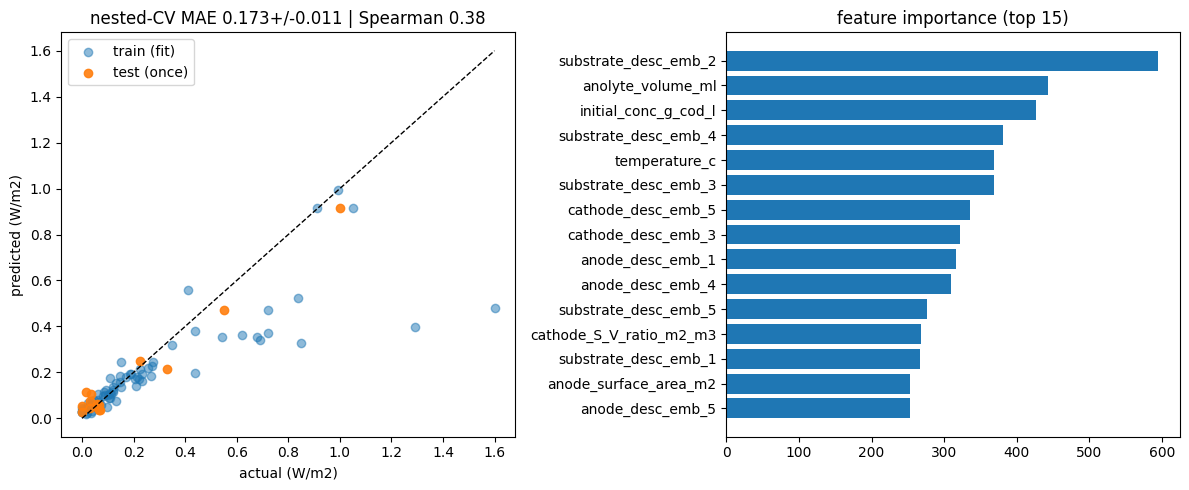

In [6]:
# DIAGNOSTIC PLOTS
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(y_train, train_pred, alpha=0.5, label="train (fit)")
ax[0].scatter(y_test, test_pred, alpha=0.9, label="test (once)")
lo = float(min(y_train.min(), y_test.min())); hi = float(max(y_train.max(), y_test.max()))
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("actual (W/m2)"); ax[0].set_ylabel("predicted (W/m2)")
ax[0].set_title("nested-CV MAE {:.3f}+/-{:.3f} | Spearman {:.2f}".format(
    nested_cv["mae_mean"], nested_cv["mae_std"], nested_cv["spearman_mean"])); ax[0].legend()
top = importance.head(15)[::-1]
ax[1].barh(top["feature"], top["importance"]); ax[1].set_title("feature importance (top 15)")
fig.tight_layout(); fig.savefig(RESULT_DIR / "diagnostic_plots.png", dpi=200, bbox_inches="tight"); plt.show()